In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/rmsd_data/new_parquets/5Å/directed_method_comparisons_rank1_with_overlap_target_pocket_rmsd_5Å.parquet")

In [3]:
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results_old/AdaptyvBio/contest_2_round_2_metrics_summary.csv")

In [4]:
pocket_merged = df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
pocket_merged = pocket_merged.drop(columns=["sequence"])

In [5]:
plot_pocket = pocket_merged[pocket_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

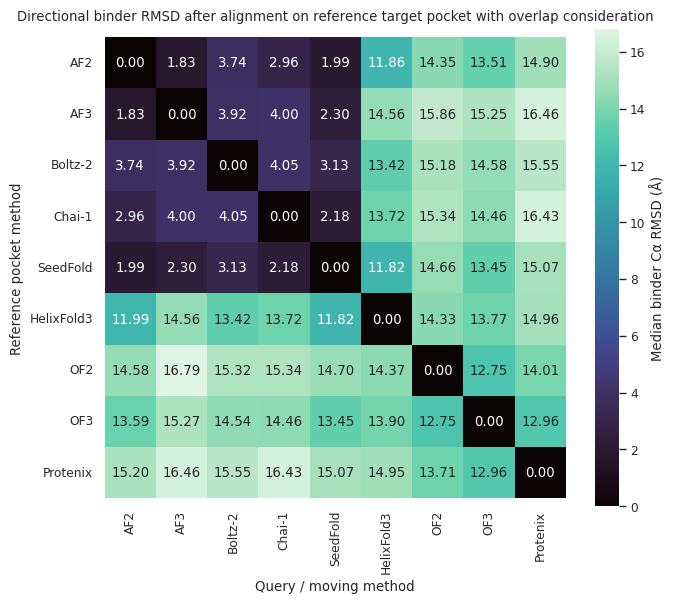

In [6]:
rmsd_col = "binder_ca_rmsd_pocket_align"

rmsd_matrix = (
    plot_pocket
    .groupby(["reference_method", "query_method"])[rmsd_col]
    .median()
    .unstack()
)

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

rmsd_matrix = rmsd_matrix.reindex(index=method_order, columns=method_order)

for m in method_order:
    if pd.isna(rmsd_matrix.loc[m, m]):
        rmsd_matrix.loc[m, m] = 0.0

sns.set_theme(style="white", context="paper")

plt.figure(figsize=(7, 6))

mask = rmsd_matrix.isna()

ax = sns.heatmap(
    rmsd_matrix,
    mask=mask,
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Median binder Cα RMSD (Å)"}
)


ax.set_title("Directional binder RMSD after alignment on reference target pocket with overlap consideration", pad=12)
ax.set_ylabel("Reference pocket method")
ax.set_xlabel("Query / moving method")

plt.tight_layout()
plt.show()

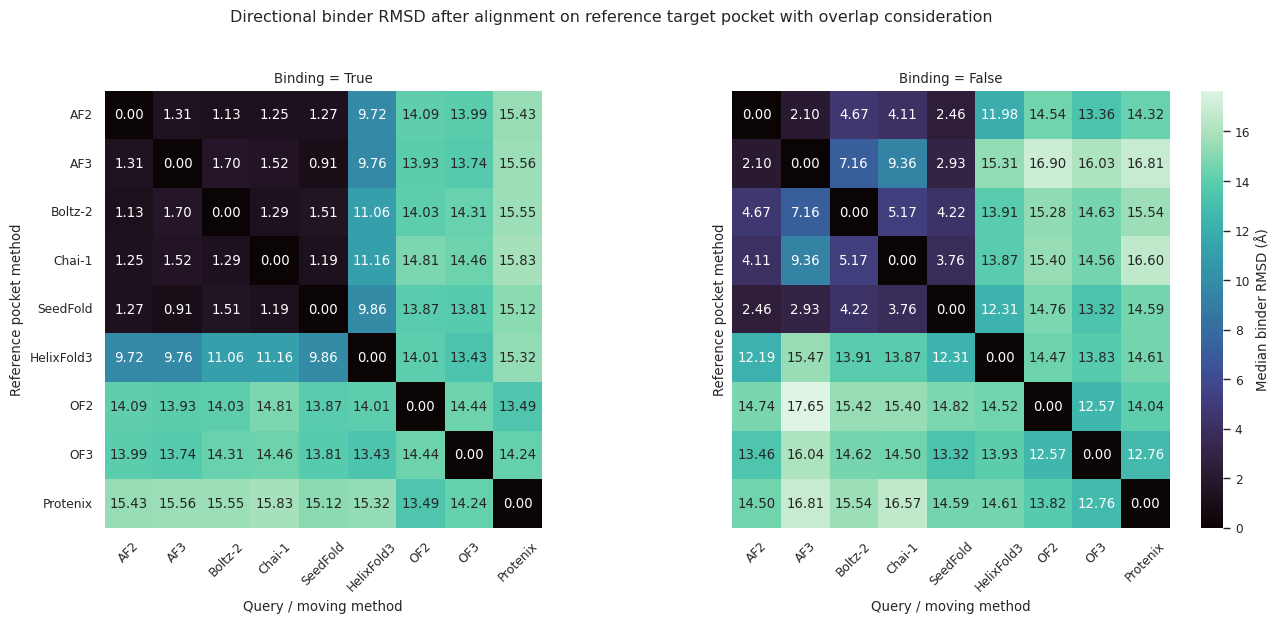

In [7]:
rmsd_col = "binder_ca_rmsd_pocket_align"

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

def make_rmsd_matrix(df):
    matrix = (
        df
        .groupby(["reference_method", "query_method"])[rmsd_col]
        .median()
        .unstack()
    )

    matrix = matrix.reindex(index=method_order, columns=method_order)

    for m in method_order:
        matrix.loc[m, m] = 0.0

    return matrix

binding_matrix = make_rmsd_matrix(
    plot_pocket[plot_pocket["binding"] == True]
)

nonbinding_matrix = make_rmsd_matrix(
    plot_pocket[plot_pocket["binding"] == False]
)

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

vmin = min(binding_matrix.min().min(), nonbinding_matrix.min().min())
vmax = max(binding_matrix.max().max(), nonbinding_matrix.max().max())

sns.heatmap(
    binding_matrix,
    ax=axes[0],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar=False
)

sns.heatmap(
    nonbinding_matrix,
    ax=axes[1],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": "Median binder RMSD (Å)"}
)

axes[0].set_title("Binding = True")
axes[1].set_title("Binding = False")

for ax in axes:
    ax.set_xlabel("Query / moving method")
    ax.set_ylabel("Reference pocket method")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Directional binder RMSD after alignment on reference target pocket with overlap consideration",
    y=1.03
)

plt.tight_layout()
plt.show()

In [8]:
ref = "AF3"
rmsd_col = "binder_ca_rmsd_pocket_align"  # adjust if needed

af3_as_1 = plot_pocket[plot_pocket["reference_method"] == ref].copy()
af3_as_1["other_method"] = af3_as_1["query_method"]

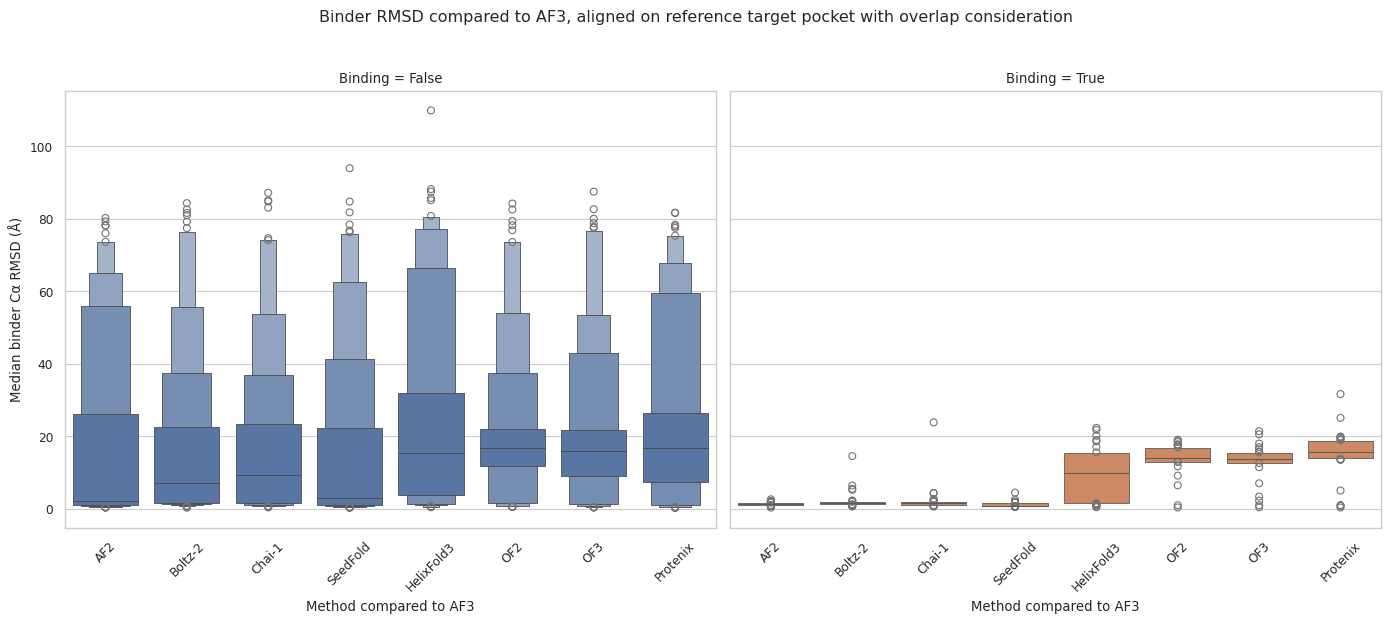

In [9]:
sns.set_theme(style="whitegrid", context="paper")

af3_nonbinding = af3_as_1[af3_as_1["binding"] == False]
af3_binding = af3_as_1[af3_as_1["binding"] == True]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

method_order = [
    "AF2", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

sns.boxenplot(
    ax=axes[0],
    data=af3_nonbinding,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    color="#4C72B0",
    width_method="linear",
    order=method_order
)


sns.boxenplot(
    ax=axes[1],
    data=af3_binding,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    color="#DD8452",
    width_method="linear",
    order=method_order
)

axes[0].set_title("Binding = False")
axes[1].set_title("Binding = True")

for ax in axes:
    ax.set_ylabel("Median binder Cα RMSD (Å)")
    ax.set_xlabel("Method compared to AF3")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Binder RMSD compared to AF3, aligned on reference target pocket with overlap consideration", y=1.03)

plt.tight_layout()
plt.show()


In [10]:
plot_pocket["interface_overlap_method_1_pct"] = (
    100 * plot_pocket["interface_overlap_method_1"]
)

plot_pocket["interface_overlap_method_2_pct"] = (
    100 * plot_pocket["interface_overlap_method_2"]
)

plot_pocket["interface_overlap_max_pct"] = (
    100 * plot_pocket["interface_overlap_max"]
)


In [11]:
plot_pocket[
    [
        "binder_sequence",
        "reference_method",
        "query_method",
        "n_interface_residues_1",
        "n_interface_residues_2",
        "n_shared_interface_residues",
        "interface_overlap_method_1_pct",
        "interface_overlap_method_2_pct",
        "interface_overlap_max_pct",
        "alignment_mode",
        "binder_ca_rmsd_pocket_align",
    ]
].head()


,binder_sequence,reference_method,query_method,n_interface_residues_1,n_interface_residues_2,n_shared_interface_residues,interface_overlap_method_1_pct,interface_overlap_method_2_pct,interface_overlap_max_pct,alignment_mode,binder_ca_rmsd_pocket_align
72,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,AF3,46,41,41,89.130435,100.000000,100.000000,shared_interface,0.686307
73,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,Boltz-2,46,53,43,93.478261,81.132075,93.478261,shared_interface,1.245337
74,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,Chai-1,46,51,40,86.956522,78.431373,86.956522,shared_interface,0.701261
75,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,HelixFold3,46,39,39,84.782609,100.000000,100.000000,shared_interface,0.813826
76,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,OF2,46,62,45,97.826087,72.580645,97.826087,shared_interface,0.356574


In [12]:
plot_pocket["alignment_mode"].value_counts(normalize=True) * 100


alignment_mode
shared_interface       87.901861
reference_interface    12.098139
Name: proportion, dtype: float64

In [13]:
plot_pocket.loc[plot_pocket["binder_ca_rmsd_pocket_align"].idxmax()]

binder_sequence                   MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...
reference_method                                                                AF3
query_method                                                             HelixFold3
structure_path_1                  /home/postyr/Assessing-AI-Scoring-Accuracy-for...
structure_path_2                  /home/postyr/Assessing-AI-Scoring-Accuracy-for...
file_type_1                                                                    .cif
file_type_2                                                                    .cif
binder_chain_1                                                                    A
binder_chain_2                                                                  A-1
target_chain_1                                                                    B
target_chain_2                                                                  B-1
score_1                                                                     

In [14]:
fallback_df = plot_pocket[
    plot_pocket["alignment_mode"] == "reference_interface"
].copy()

fallback_df["interface_overlap_method_1_pct"] = (
    100 * fallback_df["interface_overlap_method_1"]
)
fallback_df["interface_overlap_method_2_pct"] = (
    100 * fallback_df["interface_overlap_method_2"]
)
fallback_df["interface_overlap_max_pct"] = (
    100 * fallback_df["interface_overlap_max"]
)


In [15]:
fallback_df[
    [
        "binder_sequence",
        "reference_method",
        "query_method",
        "n_interface_residues_1",
        "n_interface_residues_2",
        "n_shared_interface_residues",
        "interface_overlap_method_1_pct",
        "interface_overlap_method_2_pct",
        "interface_overlap_max_pct",
        "binder_ca_rmsd_pocket_align",
        "structure_path_1",
        "structure_path_2",
    ]
].sort_values("interface_overlap_max_pct").head(20)


,binder_sequence,reference_method,query_method,n_interface_residues_1,n_interface_residues_2,n_shared_interface_residues,interface_overlap_method_1_pct,interface_overlap_method_2_pct,interface_overlap_max_pct,binder_ca_rmsd_pocket_align,structure_path_1,structure_path_2
8501,LVERTIELLRQLLEEGWGTEEEREWIEERIAILREGPSPEIVEWWL...,AF2,OF3,21,24,0,0.0,0.0,0.0,54.782695,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
8449,LSRSICPSNYDSYCLNGGQCFLAEDISGYTCMCRLGYSGRRVETFD...,Chai-1,AF3,39,46,0,0.0,0.0,0.0,45.313242,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
8457,LSRSICPSNYDSYCLNGGQCFLAEDISGYTCMCRLGYSGRRVETFD...,HelixFold3,AF3,24,46,0,0.0,0.0,0.0,46.414550,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
8462,LSRSICPSNYDSYCLNGGQCFLAEDISGYTCMCRLGYSGRRVETFD...,HelixFold3,Protenix,24,24,0,0.0,0.0,0.0,59.756801,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
8465,LSRSICPSNYDSYCLNGGQCFLAEDISGYTCMCRLGYSGRRVETFD...,OF2,AF3,64,46,0,0.0,0.0,0.0,44.842739,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
8473,LSRSICPSNYDSYCLNGGQCFLAEDISGYTCMCRLGYSGRRVETFD...,OF3,AF3,36,46,0,0.0,0.0,0.0,43.652521,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
8481,LSRSICPSNYDSYCLNGGQCFLAEDISGYTCMCRLGYSGRRVETFD...,Protenix,AF3,24,46,0,0.0,0.0,0.0,63.197831,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
8105,LKEELKKLLKELLEKGWPPEKHKEWINERIAIIEEGPIPRILKWWL...,OF2,AF3,45,21,0,0.0,0.0,0.0,73.534840,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
23510,SKRELIEEFLNIHSWFIEQCVDNTSLDSDEIKKKVEEHFDKLLLEM...,HelixFold3,AF2,20,40,0,0.0,0.0,0.0,49.056225,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
23511,SKRELIEEFLNIHSWFIEQCVDNTSLDSDEIKKKVEEHFDKLLLEM...,HelixFold3,AF3,20,27,0,0.0,0.0,0.0,47.835051,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...


In [16]:
fallback_df[
    fallback_df["interface_overlap_max"].between(0.40, 0.50)
][
    [
        "binder_sequence",
        "reference_method",
        "query_method",
        "n_interface_residues_1",
        "n_interface_residues_2",
        "n_shared_interface_residues",
        "interface_overlap_method_1_pct",
        "interface_overlap_method_2_pct",
        "interface_overlap_max_pct",
        "binder_ca_rmsd_pocket_align",
        "structure_path_1",
        "structure_path_2",
    ]
].sort_values("interface_overlap_max_pct", ascending=False).head(20)


,binder_sequence,reference_method,query_method,n_interface_residues_1,n_interface_residues_2,n_shared_interface_residues,interface_overlap_method_1_pct,interface_overlap_method_2_pct,interface_overlap_max_pct,binder_ca_rmsd_pocket_align,structure_path_1,structure_path_2
6040,GIFGVVFKADIARVSIDVAIDYSTGYLGSLTTFSGCNQ,SeedFold,AF2,47,53,23,48.936170,43.396226,48.936170,32.068916,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
5983,GIFGVVFKADIARVSIDVAIDYSTGYLGSLTTFSGCNQ,AF2,SeedFold,53,47,23,43.396226,48.936170,48.936170,10.207563,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
1962,DEGIENFVNFMKKSQEMMKGNDEERREWHAWMRVMLEKSTNKDMTE...,Boltz-2,Chai-1,43,45,21,48.837209,46.666667,48.837209,32.242000,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
1970,DEGIENFVNFMKKSQEMMKGNDEERREWHAWMRVMLEKSTNKDMTE...,Chai-1,Boltz-2,45,43,21,46.666667,48.837209,48.837209,30.649703,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
12910,NSPNLCPPSHDGYCKHGGKCYYIPALNKYACNCVVGYIGERCQYRD...,Boltz-2,Protenix,44,39,19,43.181818,48.717949,48.717949,36.191327,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
12946,NSPNLCPPSHDGYCKHGGKCYYIPALNKYACNCVVGYIGERCQYRD...,Protenix,Boltz-2,39,44,19,48.717949,43.181818,48.717949,16.519194,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
12951,NSPNLCPPSHDGYCKHGGKCYYIPALNKYACNCVVGYIGERCQYRD...,Protenix,SeedFold,39,41,19,48.717949,46.341463,48.717949,16.435031,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
12959,NSPNLCPPSHDGYCKHGGKCYYIPALNKYACNCVVGYIGERCQYRD...,SeedFold,Protenix,41,39,19,46.341463,48.717949,48.717949,35.045011,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
9680,MKLSHLLRNGPRMFNQGTGVDFWGACEIGIINYGCGKGSY,HelixFold3,AF2,39,50,19,48.717949,38.000000,48.717949,34.245286,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
9651,MKLSHLLRNGPRMFNQGTGVDFWGACEIGIINYGCGKGSY,AF2,HelixFold3,50,39,19,38.000000,48.717949,48.717949,12.308421,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...


In [17]:
fallback_df[
    [
        "binder_sequence",
        "reference_method",
        "query_method",
        "interface_overlap_max_pct",
        "binder_ca_rmsd_pocket_align",
        "n_interface_residues_1",
        "n_interface_residues_2",
        "n_shared_interface_residues",
        "structure_path_1",
        "structure_path_2",
    ]
].sort_values("binder_ca_rmsd_pocket_align", ascending=False).head(20)


,binder_sequence,reference_method,query_method,interface_overlap_max_pct,binder_ca_rmsd_pocket_align,n_interface_residues_1,n_interface_residues_2,n_shared_interface_residues,structure_path_1,structure_path_2
11027,MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...,AF3,HelixFold3,0.0,109.816678,14,17,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
11049,MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...,HelixFold3,AF3,0.0,104.297014,17,14,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
14862,QMQLSQSGPGLVQPGQSSRITGAVSGFSHMNYGTHWYRQAPRKTLE...,Chai-1,Protenix,0.0,102.304503,14,34,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
24334,SPDEAEELLKKAEELARKQNNELELNYIDFLKHVLENAKRLNDKEA...,SeedFold,AF2,0.0,96.540668,28,27,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
24335,SPDEAEELLKKAEELARKQNNELELNYIDFLKHVLENAKRLNDKEA...,SeedFold,AF3,0.0,95.279489,28,23,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
24341,SPDEAEELLKKAEELARKQNNELELNYIDFLKHVLENAKRLNDKEA...,SeedFold,Protenix,0.0,95.116935,28,24,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
24285,SPDEAEELLKKAEELARKQNNELELNYIDFLKHVLENAKRLNDKEA...,AF3,SeedFold,0.0,93.897214,23,28,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
24333,SPDEAEELLKKAEELARKQNNELELNYIDFLKHVLENAKRLNDKEA...,Protenix,SeedFold,0.0,93.862782,24,28,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
24277,SPDEAEELLKKAEELARKQNNELELNYIDFLKHVLENAKRLNDKEA...,AF2,SeedFold,0.0,93.762796,27,28,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
1326,ATPYGTPASAYRK,Chai-1,Protenix,0.0,93.461030,14,20,0,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...


In [18]:
binder_overlap_summary = plot_pocket.groupby("binder_sequence").agg(
    mean_overlap_max_pct=("interface_overlap_max_pct", "mean"),
    median_overlap_max_pct=("interface_overlap_max_pct", "median"),
    n_comparisons=("interface_overlap_max_pct", "count"),
    pct_reference_interface=(
        "alignment_mode",
        lambda x: 100 * (x == "reference_interface").mean()
    ),
    pct_shared_interface=(
        "alignment_mode",
        lambda x: 100 * (x == "shared_interface").mean()
    ),
).reset_index()


In [19]:
binder_overlap_summary[
    [
        "mean_overlap_max_pct",
        "median_overlap_max_pct",
        "pct_reference_interface",
        "pct_shared_interface",
        "n_comparisons",
    ]
].describe()


,mean_overlap_max_pct,median_overlap_max_pct,pct_reference_interface,pct_shared_interface,n_comparisons
count,197.000000,197.000000,197.000000,197.000000,197.0
mean,75.975355,80.438464,12.098139,87.901861,72.0
std,13.058411,13.809015,15.515730,15.515730,0.0
min,28.700521,0.000000,0.000000,33.333333,72.0
25%,66.370591,75.595238,0.000000,77.777778,72.0
50%,80.906582,84.375000,2.777778,97.222222,72.0
75%,84.850696,88.888889,22.222222,100.000000,72.0
max,98.962438,100.000000,66.666667,100.000000,72.0
